<a href="https://colab.research.google.com/github/AnzorGozalishvili/IOAI-2025-lectures/blob/main/lecture_31_transformers_finetuning_on_classification/notebooks/Davit6174_georgian_distilbert_mlm_%26_DGurgurov_georgian_sa_Sentiment_Analysis_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Davit6174/georgian-distilbert-mlm
- Model Card: https://huggingface.co/Davit6174/georgian-distilbert-mlm
- Dataset Source (for tokenizer test): https://huggingface.co/datasets/DGurgurov/georgian_sa/viewer/default/test?views%5B%5D=test

In [1]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
from transformers import pipeline

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("Davit6174/georgian-distilbert-mlm")
# Load the PyTorch model instead of the TensorFlow model
model = AutoModelForMaskedLM.from_pretrained("Davit6174/georgian-distilbert-mlm", from_tf=True)

# Build pipeline
mask_filler = pipeline(
    "fill-mask", model=model, tokenizer=tokenizer
)

text = 'ქართული <mask> [MASK] სწავლა საკმაოდ რთულია'

# Generate model output
preds = mask_filler(text)

# Print top 5 predictions
for pred in preds:
    print(f">>> {pred['sequence']}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/526k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/998k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/524 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

All TF 2.0 model weights were used when initializing DistilBertForMaskedLM.

Some weights of DistilBertForMaskedLM were not initialized from the TF 2.0 model and are newly initialized: ['vocab_projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


>>> ქართული < mask > ქართული სწავლა საკმაოდ რთულია
>>> ქართული < mask > - სწავლა საკმაოდ რთულია
>>> ქართული < mask > > სწავლა საკმაოდ რთულია
>>> ქართული < mask >, სწავლა საკმაოდ რთულია
>>> ქართული < mask > სწავლა სწავლა საკმაოდ რთულია


# Prepare Model For Sentiment Classification

In [2]:
from transformers import AutoModelForSequenceClassification

# Load the sequence classification model
num_labels = 2 # Binary classification (positive/negative)
model = AutoModelForSequenceClassification.from_pretrained("Davit6174/georgian-distilbert-mlm", num_labels=num_labels, from_tf=True)


All TF 2.0 model weights were used when initializing DistilBertForSequenceClassification.

All the weights of DistilBertForSequenceClassification were initialized from the TF 2.0 model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use DistilBertForSequenceClassification for predictions without further training.


# Load Sentiment Dataset

In [3]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [4]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("DGurgurov/georgian_sa")
print(dataset)
pd.concat([pd.Series(dataset[split]['label']).value_counts().T for split in ['train', 'validation', 'test']], axis=1, keys=['train', 'validation', 'test'])

README.md:   0%|          | 0.00/2.33k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/356k [00:00<?, ?B/s]

dev.csv:   0%|          | 0.00/38.3k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/105k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1080 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/330 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1080
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 120
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 330
    })
})


,train,validation,test
0,550,50,165
1,530,70,165


# Train

In [5]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score

# Define training arguments
training_args = TrainingArguments(
    # output_dir="./sentiment_classification_results",  # Output directory
    output_dir=None,
    evaluation_strategy="epoch",  # Evaluate at the end of each epoch
    learning_rate=2e-5,  # Learning rate
    per_device_train_batch_size=16,  # Batch size per device during training
    per_device_eval_batch_size=16,  # Batch size for evaluation
    num_train_epochs=3,  # Number of training epochs
    weight_decay=0.01,  # Weight decay
    push_to_hub=False,  # Whether to upload the model to the Hugging Face Model Hub
    # logging_dir='./logs',
    logging_dir=None,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    # Align save_strategy with evaluation_strategy
    save_strategy="epoch",
    report_to="none",
)

# Function to tokenize the dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Tokenize the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Function to compute metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# Create Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],  # Use the tokenized training dataset
    eval_dataset=tokenized_datasets["validation"],  # Use the tokenized validation dataset
    tokenizer=tokenizer,
    compute_metrics=compute_metrics, # Pass the compute_metrics function

)

# Train the model
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

<ipython-input-5-974f810e3828>:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.524100,0.463062,0.825000
2,0.446000,0.413283,0.783333
3,0.354400,0.370959,0.833333


TrainOutput(global_step=204, training_loss=0.4657120926707399, metrics={'train_runtime': 174.8394, 'train_samples_per_second': 18.531, 'train_steps_per_second': 1.167, 'total_flos': 429194371645440.0, 'train_loss': 0.4657120926707399, 'epoch': 3.0})

# Explain Model Predictions

In [6]:
!pip install transformers-interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/

In [7]:
from transformers_interpret import SequenceClassificationExplainer

cls_explainer = SequenceClassificationExplainer(model, tokenizer)

In [8]:
def interpret_text(text):
  word_attributions = cls_explainer(text)
  return cls_explainer.visualize()


for text, sentiment in zip(dataset['test']['text'][:10], dataset['test']['label'][:10]):
    interpret_text(text)
    print(sentiment)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,LABEL_0 (0.65),LABEL_0,2.09,"[CLS] ყოფილი პრემ ##ეირ ##ი ხო ##კრ ##იშ ##ვილზე საუბრობს და აცხადებს , რომ მის ##თი ##ვს ის ყველაზე სიმპ ##ატი ##ური მინისტრი იყო [SEP]"


1


1


1


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,LABEL_1 (0.92),LABEL_1,1.62,[CLS] მან მადლობა გადაუხადა საქართველოს ნატოს ავღანეთის მისია ##ში შეტანილი წვლილი ##სთ ##ვის [SEP]


...

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,LABEL_0 (0.82),LABEL_0,2.84,"[CLS] რაც შეეხება გია გაჩეჩილ ##აძის მხარეს , ისინი თბილისის საქალაქო სასამართლოს მოსამართ ##ლოს გადაწყვეტილებით კმაყოფილ ##ები არიან [SEP]"


1


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,LABEL_1 (0.85),LABEL_1,1.63,[CLS] ყველას დიდი მადლობა [SEP]


1


1


## Evaluate

In [12]:
from torch.utils.data import DataLoader, TensorDataset
import torch

CLASSES = ['Negative', 'Positive']

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

label_to_id = {k:idx for idx,k in enumerate(CLASSES)}
id_to_label = {idx:k for idx,k in enumerate(CLASSES)}

def create_dataloader(dataset, tokenizer, batch_size=32, max_length=512):
    texts = [example['text'] for example in dataset]
    label_ids = [example['label'] for example in dataset]  # Assuming 'label' key exists
    labels = [id_to_label[label_id] for label_id in label_ids]

    # Tokenize the texts
    encoded_inputs = tokenizer(texts, truncation=True, padding='max_length', max_length=max_length, return_tensors='pt')

    # Create TensorDataset
    dataset = TensorDataset(encoded_inputs['input_ids'], encoded_inputs['attention_mask'], torch.tensor(label_ids))

    # Create DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # Set shuffle=False for inference

    return dataloader


# Example Usage
batch_size = 256  # Adjust as needed
val_dataloader = create_dataloader(dataset['validation'], tokenizer, batch_size=batch_size) # Use 'validation' split
test_dataloader = create_dataloader(dataset['test'], tokenizer, batch_size=batch_size) # Use 'test' split

In [13]:
next(iter(val_dataloader)), next(iter(test_dataloader))

([tensor([[    2, 23765,   243,  ...,     0,     0,     0],
          [    2, 19271,   468,  ...,     0,     0,     0],
          [    2,  3457, 11772,  ...,     0,     0,     0],
          ...,
          [    2, 10357,  7355,  ...,     0,     0,     0],
          [    2, 23978,  7005,  ...,     0,     0,     0],
          [    2,  1278, 23212,  ...,     0,     0,     0]]),
  tensor([[1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          ...,
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0]]),
  tensor([0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
          1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
          1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
          0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
          1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0

In [14]:
def predict_batch(batch, model):
    model.eval()
    input_ids, attention_mask, labels = batch
    with torch.no_grad():
        # Move inputs to the device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits.argmax(dim=1).cpu().tolist()
        probabilities = outputs.logits.softmax(dim=1).cpu().tolist()
        labels = labels.tolist()

    return predictions, probabilities, labels

batch_preds, batch_probs, batch_labels = predict_batch(batch=next(iter(val_dataloader)), model=model)
print(batch_preds[:10], batch_probs[:10], batch_labels[:10])

[0, 0, 0, 1, 1, 0, 1, 0, 1, 0] [[0.8703000545501709, 0.12969999015331268], [0.6435909271240234, 0.3564090132713318], [0.5492982268333435, 0.4507017433643341], [0.308245450258255, 0.6917545795440674], [0.0965430811047554, 0.9034568667411804], [0.9058108925819397, 0.0941891297698021], [0.22779367864131927, 0.7722062468528748], [0.846735417842865, 0.15326455235481262], [0.07053192704916, 0.929468035697937], [0.9067488312721252, 0.09325115382671356]] [0, 0, 1, 1, 1, 0, 1, 0, 1, 0]


In [15]:
from tqdm import tqdm

def batch_predict_sentiment(dataloader, model):
    all_predictions = []
    all_probabilities = []
    all_labels = []

    for batch in tqdm(dataloader):
        predictions, probabilities, labels = predict_batch(batch, model)

        all_predictions.extend(predictions)
        all_labels.extend(labels)
        all_probabilities.extend(probabilities)

    return all_predictions, all_probabilities, all_labels

val_predictions, val_probabilities, val_labels = batch_predict_sentiment(val_dataloader, model)
test_predictions, test_probabilities, test_labels = batch_predict_sentiment(test_dataloader, model)

100%|██████████| 2/2 [00:10<00:00,  5.12s/it]


              precision    recall  f1-score   support

    Negative       0.76      0.88      0.81        50
    Positive       0.90      0.80      0.85        70

    accuracy                           0.83       120
   macro avg       0.83      0.84      0.83       120
weighted avg       0.84      0.83      0.83       120



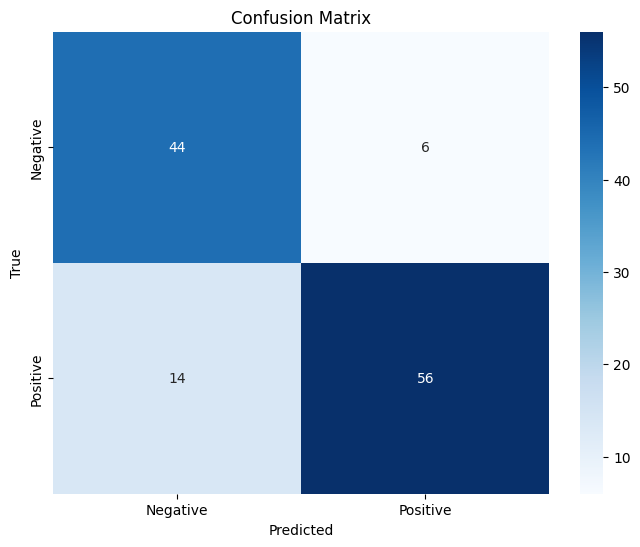

Macro F1-Score: 0.8316498316498316
AUC-ROC (OVO, macro): 0.9220000000000002
              precision    recall  f1-score   support

    Negative       0.79      0.82      0.80       165
    Positive       0.81      0.78      0.80       165

    accuracy                           0.80       330
   macro avg       0.80      0.80      0.80       330
weighted avg       0.80      0.80      0.80       330



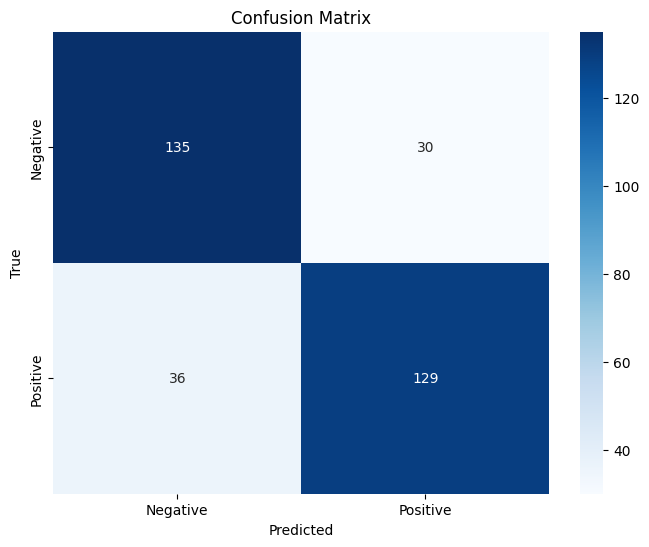

Macro F1-Score: 0.7999338624338624
AUC-ROC (OVO, macro): 0.8827180899908172


In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def classification_reports(true_labels, predicted_labels, predicted_probabilities):

    # Classification Report
    print(classification_report(true_labels, predicted_labels, target_names=CLASSES))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES,
                yticklabels=CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # F1-Score (macro average)
    f1 = f1_score(true_labels, predicted_labels, average='macro')
    print(f"Macro F1-Score: {f1}")


    # AUC-ROC (requires probabilities)
    try:
        auc_roc = roc_auc_score(np.eye(4)[true_labels], np.array(predicted_probabilities), multi_class='ovo', average='macro')
        print(f"AUC-ROC (OVO, macro): {auc_roc}")
    except ValueError as e:
        print(f"AUC-ROC Calculation failed: {e}")

classification_reports(true_labels=val_labels, predicted_labels=val_predictions, predicted_probabilities=val_probabilities)
classification_reports(true_labels=test_labels, predicted_labels=test_predictions, predicted_probabilities=test_probabilities)